In [2]:
!pwd

/home/dwalicki/Projekty/MaterialsVision/notebooks


In [1]:
from pathlib import Path

files_path = '/home/dwalicki/dane/dotrenowanie_2'
files = Path(files_path).glob('*.jpg')
files = [file for file in files if file.is_file()]

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from cellpose import models, io
from cellpose.io import imread

io.logger_setup()

model_path = '/mnt/c/Projekty/cpsam-40-50_train augmented - only 40 & 50 magnifications_20251105_084436'

model = models.CellposeModel(gpu=True, pretrained_model=model_path)

OUTPUT_PATH = '/home/dwalicki/Projekty/dotrenowanie_2'

# list of files

imgs = [imread(f) for f in files]
nimg = len(imgs)

masks, flows, styles = model.eval(imgs)

2026-03-25 21:10:49,789 [INFO] WRITING LOG OUTPUT TO /home/dwalicki/.cellpose/run.log
2026-03-25 21:10:49,790 [INFO] 
cellpose version: 	4.0.8 
platform:       	linux 
python version: 	3.12.3 
torch version:  	2.9.1+cu128
2026-03-25 21:10:50,142 [INFO] ** TORCH CUDA version installed and working. **
2026-03-25 21:10:50,143 [INFO] >>>> using GPU (CUDA)
2026-03-25 21:10:51,954 [INFO] >>>> loading model /mnt/c/Projekty/cpsam-40-50_train augmented - only 40 & 50 magnifications_20251105_084436


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from cellpose import models, io
from cellpose.io import imread
from pathlib import Path

In [26]:
io.logger_setup()

model_path = '/mnt/c/Projekty/cpsam-40-50_train augmented - only 40 & 50 magnifications_20251105_084436'

model = models.CellposeModel(gpu=True, pretrained_model=model_path)

OUTPUT_PATH = '/home/dwalicki/Projekty/dotrenowanie_2'

2026-03-25 21:22:26,733 [INFO] WRITING LOG OUTPUT TO /home/dwalicki/.cellpose/run.log
2026-03-25 21:22:26,733 [INFO] 
cellpose version: 	4.0.8 
platform:       	linux 
python version: 	3.12.3 
torch version:  	2.9.1+cu128
2026-03-25 21:22:26,734 [INFO] ** TORCH CUDA version installed and working. **
2026-03-25 21:22:26,735 [INFO] >>>> using GPU (CUDA)
2026-03-25 21:22:28,593 [INFO] >>>> loading model /mnt/c/Projekty/cpsam-40-50_train augmented - only 40 & 50 magnifications_20251105_084436


In [45]:
files_path = '/home/dwalicki/dane/dotrenowanie_2'
files = Path(files_path).glob('*.png')
files = [file for file in files if file.is_file()]

imgs = [imread(f) for f in files]
imgs = [img[0:750, :] for img in imgs]
nimg = len(imgs)

masks, flows, styles = model.eval(imgs)

2026-03-25 21:43:52,594 [INFO] processing image with (750, 1083) HW, and 3 channels


In [42]:
imgs = [imread(f) for f in files]
print(imgs[0].shape)
imgs[0][0:750, :].shape

(817, 1083, 3)


(750, 1083, 3)

In [46]:
from tifffile import imwrite
for input_file, mask in zip(files, masks):
    output_filename = f"{input_file.stem}_predicted_masks.tif"
    output_path = Path(OUTPUT_PATH) / output_filename
    
    try:
        imwrite(output_path, mask)
        print(f"✓ Saved: {output_filename}")
    except Exception as e:
        print(f"✗ Error saving {output_filename}: {e}")

✓ Saved: zdj_vab_0_predicted_masks.tif


In [10]:
mask

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(817, 1083), dtype=uint16)

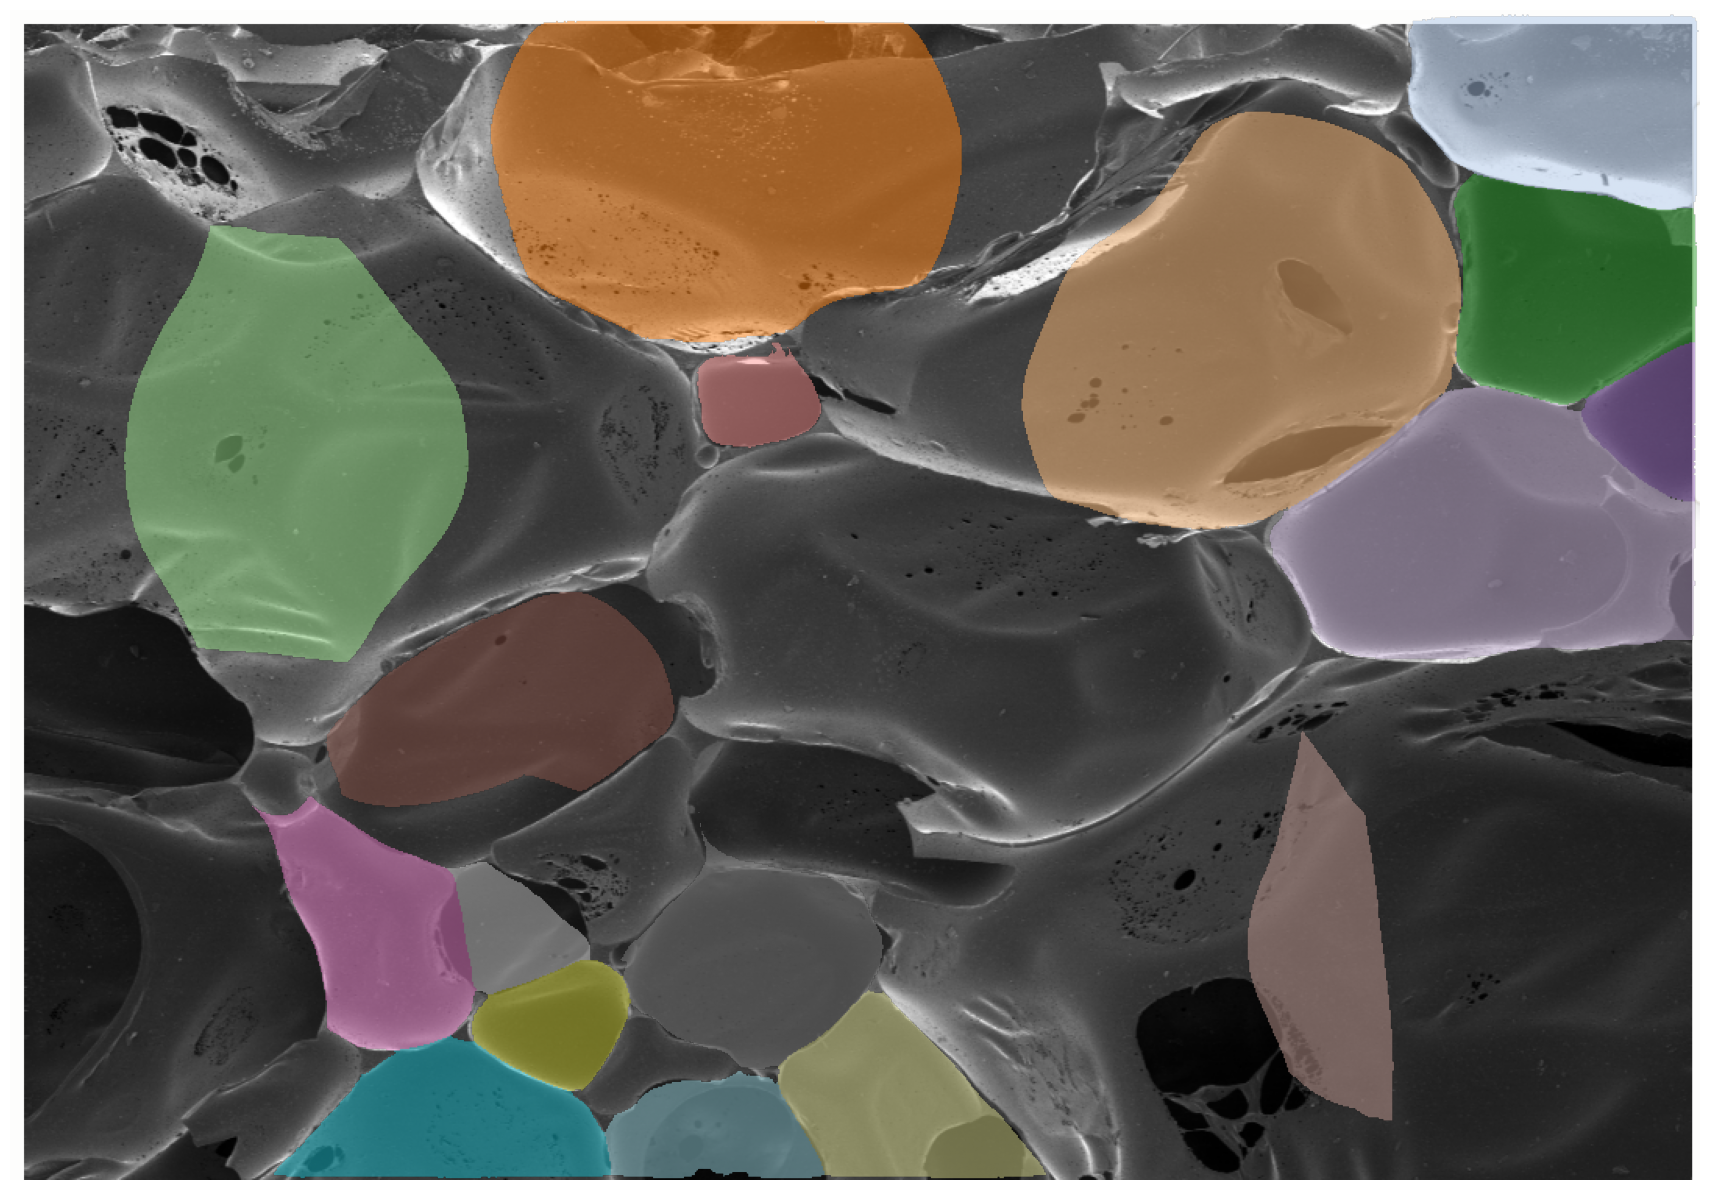

In [47]:
cmap = plt.cm.tab20
overlay = cmap(mask.astype(float) / mask.max())  # RGBA
overlay[mask == 0] = [0, 0, 0, 0]  # tło przezroczyste

fig, ax = plt.subplots(figsize=(18, 12))
ax.imshow(imgs[0])
ax.imshow(overlay, alpha=0.5)
ax.axis('off')
plt.tight_layout()
plt.savefig("overlay.png", dpi=150, bbox_inches='tight')
plt.show()